In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import time

state = [cosθ1, sinθ1, cosθ2, sinθ2, θ̇1, θ̇2]  
total number of states = 10^6  
actions = { -1 torque, 0 torque, +1 torque }  
Q-table size = (10^6) * 3


function to discretize state  
action funciton to apply torque  
sarsa and q learning func (Q = Q + alpha*(r + gamma*Q' - Q))  
policy - epsilon greedy (known state and action decided based on best Q)

In [2]:
def discretize(obs, bins):
    return tuple(
        np.digitize(obs[i], bins[i])
        for i in range(len(obs))
    )

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(3)
    return np.argmax(Q[state])

In [ ]:
num_bins = 10
gamma = 0.99
episodes=5000
alpha=0.1
epsilon_start=1.0
epsilon_min=0.1
epsilon_decay=0.998  # * Reaches 0.1 at around 1150 episodes  
max_steps=500

In [45]:
def make_bins(num_bins):
    bins = []

    # cos and sin ∈ [-1,1]
    for _ in range(4):
        bins.append(np.linspace(-1, 1, num_bins - 1))

    # velocities (use env limits)
    bins.append(np.linspace(-4*np.pi, 4*np.pi, num_bins - 1))
    bins.append(np.linspace(-9*np.pi, 9*np.pi, num_bins - 1))
    return bins

In [27]:
def plot_returns(returns, alpha=0.1):
    plt.figure()
    returns = np.array(returns)

    # Plot raw returns with transparency
    plt.plot(returns, alpha=0.3, label='Raw Returns')

    # Compute EMA
    ema = np.zeros_like(returns)
    if len(returns) > 0:
        ema[0] = returns[0]
        for t in range(1, len(returns)):
            # EMA formula: current_smoothed = alpha * current_raw + (1 - alpha) * prev_smoothed
            ema[t] = alpha * returns[t] + (1 - alpha) * ema[t-1]
        
        plt.plot(ema, label=f'EMA (alpha={alpha})', linewidth=2)

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Return vs Episode")
    plt.legend()
    plt.grid(True)
    plt.show()

In [60]:
def visualize_policy(Q, episodes=3, max_steps=500, num_bins=10):
    env = gym.make("Acrobot-v1", render_mode="human")
    bins = make_bins(num_bins)

    for _ in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)

        for _ in range(max_steps):

            # Greedy action (no exploration)
            action = np.argmax(Q[state])

            obs, _, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)

            if terminated or truncated:
                break

    env.close()

def get_return(Q, max_steps=500, num_bins=10, episodes=100):
    bins = make_bins(num_bins)
    env = gym.make("Acrobot-v1")

    returns = []

    for _ in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)

        reward_sum = 0

        for _ in range(max_steps):

            # Greedy action (no exploration)
            action = np.argmax(Q[state])

            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)
            reward_sum += reward  # Each step gives a reward of -1, so we can just count steps

            if terminated or truncated:
                break
    
        returns.append(reward_sum)

    env.close()
    return np.mean(returns), np.var(returns)


def visualize_policy_notebook(Q, episodes=3, max_steps=500, online=False, num_bins=10):
        
    envs = [gym.make("Acrobot-v1", render_mode="rgb_array") 
            for _ in range(episodes)]
    bins = make_bins()
    states = []
    dones = [False] * episodes
    
    # reset all envs
    for env in envs:
        obs, _ = env.reset()
        states.append(discretize(obs, bins))

    for _ in range(max_steps):

        frames = []

        for i in range(episodes):
            if not dones[i]:
                if online:
                    # epsilon-greedy action selection for online visualization
                    action = epsilon_greedy(Q, states[i], epsilon=0.1)  # No exploration
                else:
                    action = np.argmax(Q[states[i]])
                obs, _, terminated, truncated, _ = envs[i].step(action)
                states[i] = discretize(obs, bins)
                dones[i] = terminated or truncated

            frames.append(envs[i].render())

        clear_output(wait=True)

        fig, axes = plt.subplots(1, episodes, figsize=(5*episodes, 4))
        if episodes == 1:
            axes = [axes]

        for ax, frame in zip(axes, frames):
            ax.imshow(frame)
            ax.axis("off")

        plt.show()
        time.sleep(0.02)

        if all(dones):
            break

    for env in envs:
        env.close()

In [38]:
def sarsa(num_bins=10):
    env = gym.make("Acrobot-v1")
    bins = make_bins(num_bins)

    # Q-table: 10^6 states × 3 actions
    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)

    returns = []
    epsilon = epsilon_start

    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # SARSA update
            Q[state][action] += alpha * (reward + gamma * Q[state_next][action_next] - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        # epsilon decay
        # epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if ep % 500 == 0:
            print("Episode: ", ep)

    env.close()
    return Q, returns

In [8]:
Q_sarsa, returns_sarsa = sarsa()

Episode:  0
Episode:  500
Episode:  1000
Episode:  1500
Episode:  2000
Episode:  2500
Episode:  3000
Episode:  3500
Episode:  4000
Episode:  4500


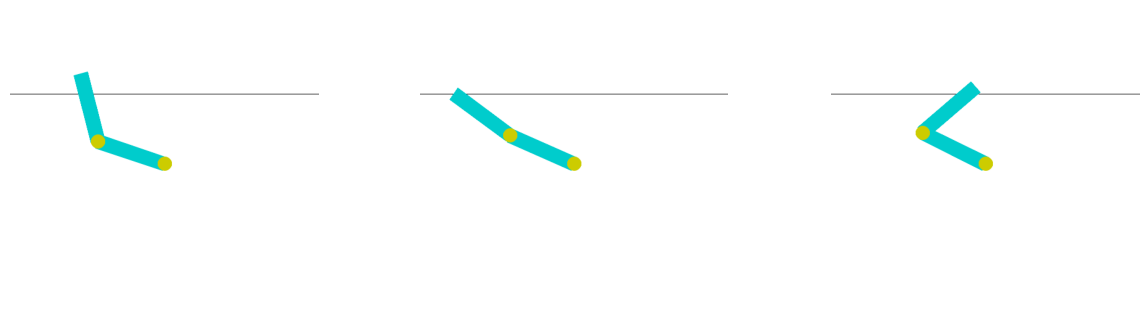

In [11]:
visualize_policy_notebook(Q_sarsa)

In [39]:
def sarsa_decay(num_bins=10):
    env = gym.make("Acrobot-v1")
    bins = make_bins(num_bins)

    # Q-table: 10^6 states × 3 actions
    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)

    returns = []
    epsilon = epsilon_start

    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # SARSA update
            Q[state][action] += alpha * (reward + gamma * Q[state_next][action_next] - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        # epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if ep % 500 == 0:
            print("Episode: ", ep)

    env.close()
    return Q, returns

In [13]:
Q_sarsa_decay, returns_sarsa_decay = sarsa_decay()

Episode:  0
Episode:  500
Episode:  1000
Episode:  1500
Episode:  2000
Episode:  2500
Episode:  3000
Episode:  3500
Episode:  4000
Episode:  4500


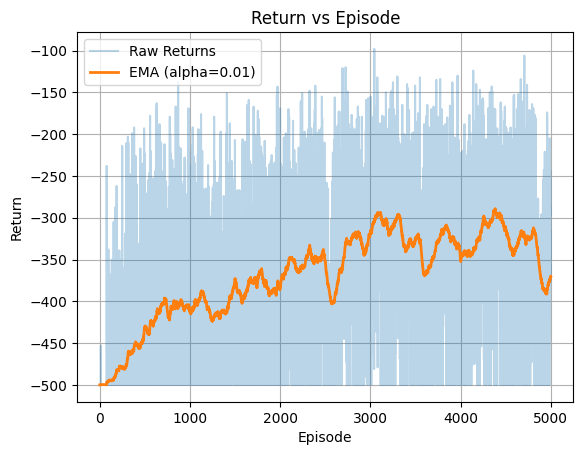

In [34]:
plot_returns(returns_sarsa_decay, 0.01)

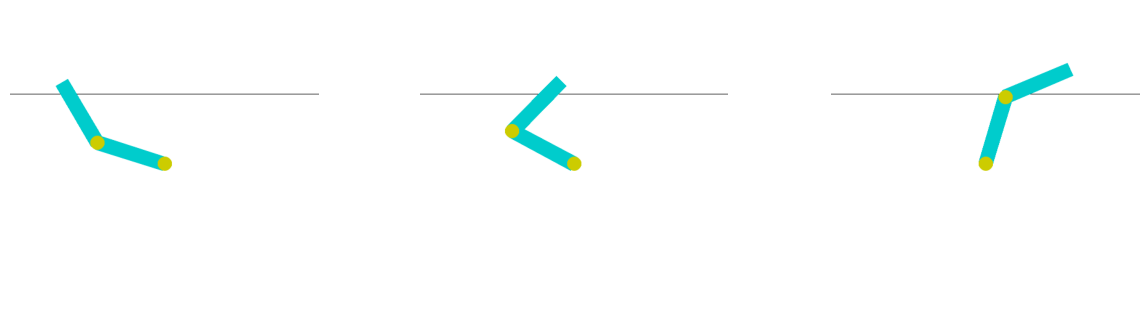

In [21]:
visualize_policy_notebook(Q_sarsa_decay, episodes=3, online=True)

In [40]:
def Q_learning_decay(num_bins=10):
    env = gym.make("Acrobot-v1")
    bins = make_bins(num_bins)

    # Q-table: 10^6 states × 3 actions
    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)

    returns = []
    epsilon = epsilon_start

    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # SARSA update
            Q[state][action] += alpha * (reward + gamma * np.max(Q[state_next]) - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        # epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if ep % 500 == 0:
            print("Episode: ", ep)

    env.close()
    return Q, returns

In [19]:
Q_QLearning_decay, returns_QLearning_decay = Q_learning_decay()
# (Q_QLearning_decay, returns_QLearning_decay)

Episode:  0
Episode:  500
Episode:  1000
Episode:  1500
Episode:  2000
Episode:  2500
Episode:  3000
Episode:  3500
Episode:  4000
Episode:  4500


(array([[[[[[[0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.],
             ...,
             [0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.]],
 
            [[0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.],
             ...,
             [0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.]],
 
            [[0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.],
             ...,
             [0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.]],
 
            ...,
 
            [[0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.],
             ...,
             [0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.]],
 
            [[0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.],
             ...,
             [0., 0., 0.],
             [0., 0., 0.],
             [0., 0., 0.]],
 
            [[0., 0., 0.],
             [0., 0., 0.],
            

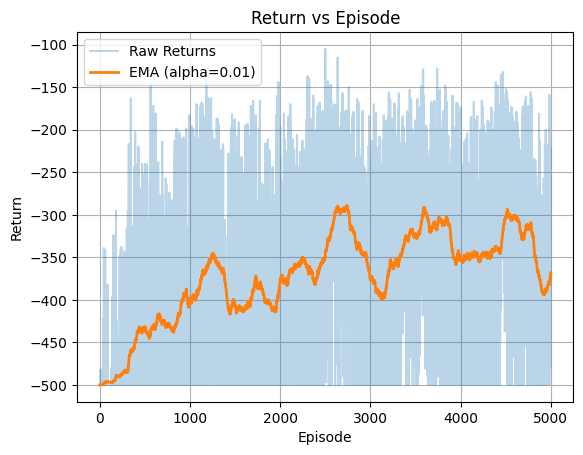

In [30]:
plot_returns(returns_QLearning_decay, 0.01)

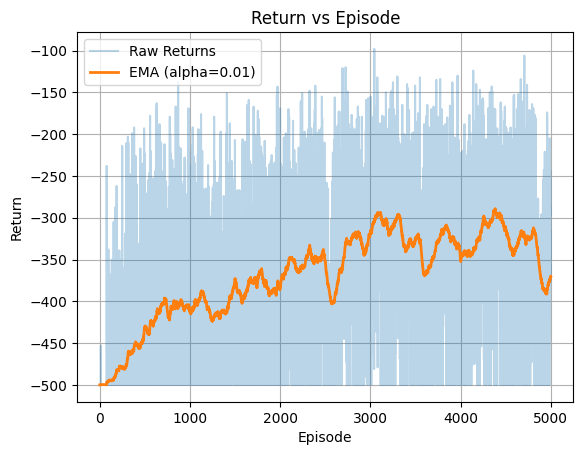

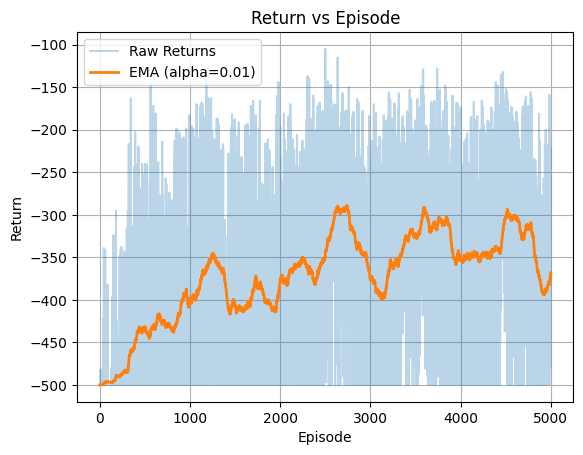

In [32]:
plot_returns(returns_sarsa_decay, 0.01)
plot_returns(returns_QLearning_decay, 0.01)

In [49]:
Q_QLearning_decay_b, returns_QLearning_decay_b = [], []

for b in [5, 15]:
    Q, returns = Q_learning_decay(num_bins=b)
    Q_QLearning_decay_b.append(Q)
    returns_QLearning_decay_b.append(returns)

Episode:  0
Episode:  500
Episode:  1000
Episode:  1500
Episode:  2000
Episode:  2500
Episode:  3000
Episode:  3500
Episode:  4000
Episode:  4500
Episode:  0
Episode:  500
Episode:  1000
Episode:  1500
Episode:  2000
Episode:  2500
Episode:  3000
Episode:  3500
Episode:  4000
Episode:  4500


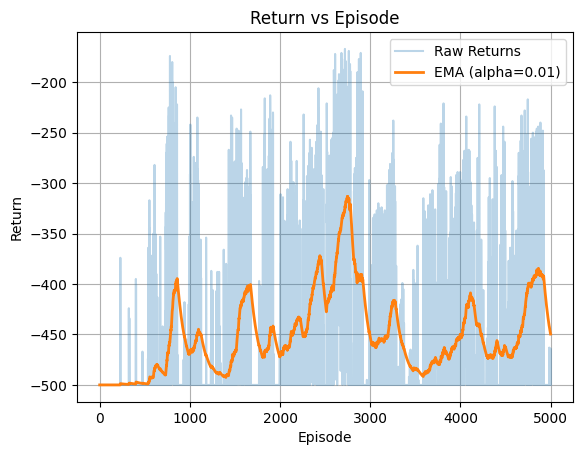

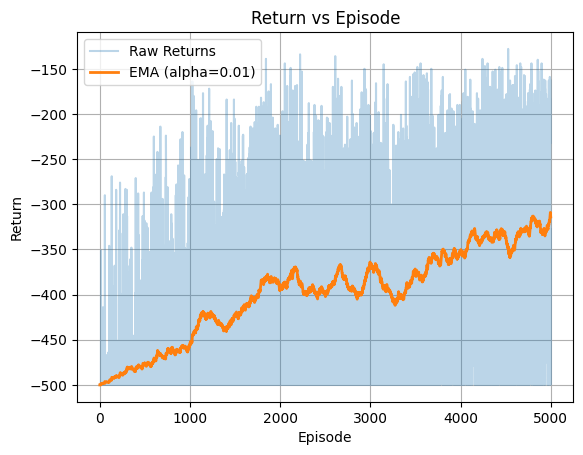

In [50]:
for b, returns in zip([5, 15], returns_QLearning_decay_b):
    plot_returns(returns, 0.01)

In [62]:
for b, Q in zip([5, 15], Q_QLearning_decay_b):
    returns = get_return(Q, num_bins=b, episodes=1000)
    print(f"Bins: {b}, Mean Return: {returns[0]}, Variance: {returns[1]}")

Bins: 5, Mean Return: -436.871, Variance: 6502.714359
Bins: 15, Mean Return: -332.973, Variance: 11770.186271


## Doubts

wtf q2? random L
q5 -> do we still ahve the termination condition